# Nonlinear Regression and Forecasting

## Will a new video keep gaining views?

A clip can gain views quickly and then slow down as fewer interested viewers remain. A saturation curve represents this pattern with an eventual audience size and a spread rate.

<img src="https://raw.githubusercontent.com/sonamu-jun/introduction-to-ai-convergence/main/06-1_Regression/assets/05_video_reach.png" alt="A simulated video gains views quickly, then approaches an audience ceiling as fewer interested viewers remain." width="640" style="max-width:100%;height:auto;">

The audience control changes the curve's ceiling. The spread-rate control changes how quickly it approaches that ceiling. These quantities interact, making the model nonlinear in its parameters. A curved line alone does not make a model nonlinear; polynomial regression uses curved features with linear coefficients.

Filled dots are recorded views during the first 12 hours. Open dots show predictions at the same times. The gaps reveal whether the selected curve follows those records. A video need not follow this pattern in reality: a repost can introduce a new audience.


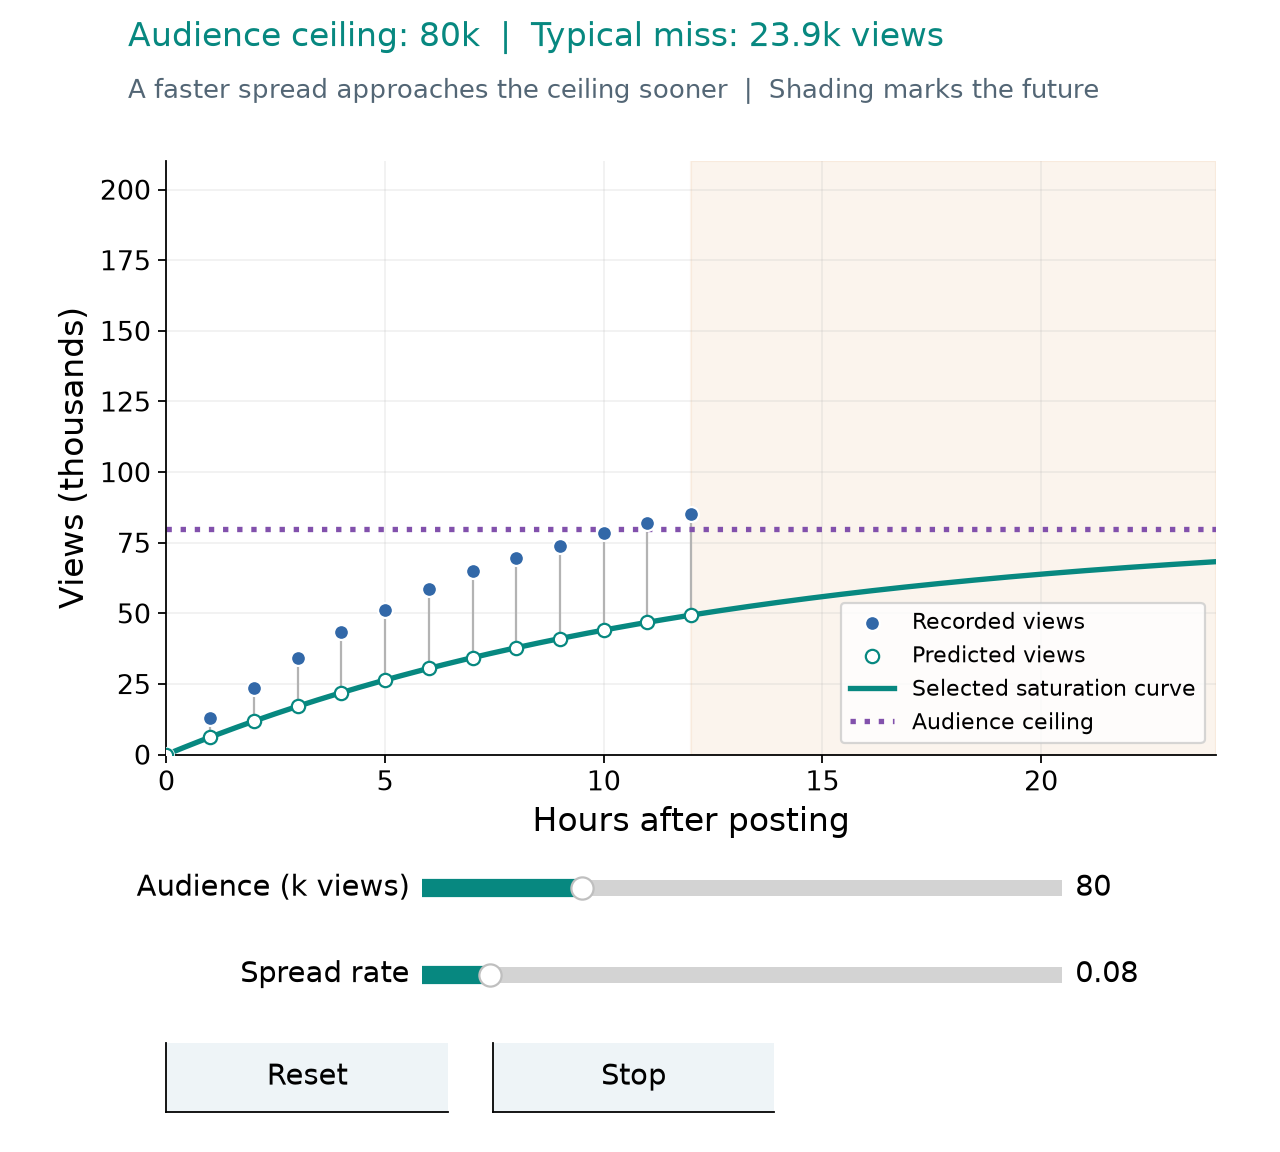

In [1]:
import os
import sys
import io
import numpy as np
import pandas as pd
import matplotlib

REGRESSION_STATIC = os.environ.get("REGRESSION_STATIC") == "1"
REGRESSION_BROWSER = sys.platform == "emscripten"
if not REGRESSION_STATIC and not REGRESSION_BROWSER:
    from IPython import get_ipython
    shell = get_ipython()
    if shell is not None and getattr(shell, "kernel", None) is not None:
        shell.run_line_magic("matplotlib", "widget")

import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button
from matplotlib.patches import Rectangle
from IPython.display import Image, display
from sklearn.linear_model import LinearRegression

plt.rcParams.update({
    "font.size": 15, "axes.labelsize": 15,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.18, "lines.linewidth": 2.4,
    "axes.unicode_minus": False, "figure.facecolor": "white",
})
BLUE, TEAL, ORANGE, PURPLE = "#3268a8", "#078880", "#d87522", "#8251ac"


def metrics(observed, predicted):
    """R² is undefined for a constant evaluation target."""
    observed = np.asarray(observed, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    error = observed - predicted
    mse = np.mean(error**2)
    total = np.sum((observed - observed.mean())**2)
    return {"MAE": np.mean(np.abs(error)), "MSE": mse,
            "RMSE": np.sqrt(mse),
            "R²": 1 - np.sum(error**2) / total if total > 0 else np.nan}


# Close earlier views before replacing models or shared callbacks on a rerun.
for _previous_view in globals().get("_regression_views", {}).values():
    _previous_view.close()
_regression_views = {}


class RegressionExplorer:
    """Sliders redraw the model and its metrics from the same observations."""

    def __init__(self, name, render, sliders, actions=(), history=False):
        previous = _regression_views.get(name)
        if previous is not None:
            previous.close()
        self.render = render
        self.running = False
        self.controls, self.buttons, self.state = {}, {}, {}
        self.defaults = {key: initial for key, label, low, high, initial, step, fmt in sliders}
        # 80 dpi gives a 640 px live canvas; saved output uses 160 dpi at the same display size.
        with plt.ioff():
            self.figure = plt.figure(figsize=(8, 8.4 if history else 7.2), dpi=80)
        self.status = self.figure.text(.10, .96, "", fontsize=15, color=TEAL)
        self.detail = self.figure.text(.10, .915, "", fontsize=11.5, color="#536675")
        bottom = .27 + .075 * (len(sliders) - 1)
        if history:
            self.ax = self.figure.add_axes([.13, .56, .82, .30])
            self.history_ax = self.figure.add_axes([.13, .33, .82, .12])
        else:
            self.ax = self.figure.add_axes([.13, bottom, .82, .86 - bottom])
        for i, (key, label, low, high, initial, step, fmt) in enumerate(sliders):
            y = .14 + .075 * (len(sliders) - i - 1)
            slider = Slider(self.figure.add_axes([.33, y, .50, .028]),
                            label, low, high, valinit=initial, valstep=step,
                            valfmt=fmt, color=TEAL)
            slider.label.set_fontsize(13)
            slider.valtext.set_fontsize(13)
            slider.on_changed(self.update)
            self.controls[key] = slider
        commands = list(actions) + [("Reset", lambda view: view.reset()),
                                    ("Stop", lambda view: view.stop())]
        width = min(.22, .8 / len(commands) - .025)
        for i, (label, callback) in enumerate(commands):
            button = Button(self.figure.add_axes([.13 + i*(width+.035), .035, width, .06]),
                            label, color="#eef4f7", hovercolor="#d7e9e6")
            button.label.set_fontsize(13)
            button.on_clicked(lambda event, callback=callback: callback(self))
            self.buttons[label] = button
        self.figure.canvas.mpl_connect("close_event", lambda event: self.stop())
        _regression_views[name] = self
        self.update()

    def update(self, _=None):
        self.ax.clear()
        if hasattr(self, "history_ax"):
            self.history_ax.clear()
        values = {key: slider.val for key, slider in self.controls.items()}
        self.state = self.render(self, **values)
        self.figure.canvas.draw_idle()

    def set_values(self, **values):
        for key, value in values.items():
            slider = self.controls[key]
            events, drawing = slider.eventson, slider.drawon
            slider.eventson = slider.drawon = False
            slider.set_val(value)
            slider.eventson, slider.drawon = events, drawing
        self.update()

    def reset(self):
        self.set_values(**self.defaults)

    def start(self):
        if REGRESSION_STATIC:
            buffer = io.BytesIO()
            self.figure.savefig(buffer, format="png", dpi=160, facecolor="white")
            display(Image(data=buffer.getvalue(), width=640,
                          alt=self.status.get_text() + ". " + self.detail.get_text()))
            plt.close(self.figure)
            return
        self.running = True
        if REGRESSION_BROWSER:
            # The browser dispatches input after the cell returns.
            plt.show(block=False)
        elif hasattr(self.figure.canvas, "toolbar_visible"):
            self.figure.canvas.toolbar_visible = False
            self.figure.canvas.header_visible = False
            self.figure.canvas.footer_visible = False
            self.figure.canvas.resizable = False
            display(self.figure.canvas)
        else:
            plt.show(block=False)

    def stop(self):
        self.running = False
        for slider in self.controls.values():
            slider.set_active(False)
        for button in self.buttons.values():
            button.set_active(False)
        self.buttons["Stop"].label.set_text("Stopped")
        self.figure.canvas.draw_idle()

    def close(self):
        self.stop()
        plt.close(self.figure)

rng_video = np.random.default_rng(62)
reach_scale, time_scale = 120., 12.
video_time = np.arange(25, dtype=float)


def video_mean(time):
    return 120 * (1-np.exp(-.13*np.asarray(time)))


# Positive hourly increments keep the synthetic cumulative count monotone.
expected_increments = np.diff(video_mean(video_time))
recorded_increments = expected_increments * np.clip(1+rng_video.normal(0, .12, 24), .3, 1.7)
video_observed = np.r_[0., np.cumsum(recorded_increments)]
video_time_train, video_views_train = video_time[:13], video_observed[:13]
video_time_future, video_views_future = video_time[13:], video_observed[13:]
video_grid = np.linspace(0, 24, 300)
video_train_grid = np.linspace(0, 12, 180)
u_train, z_train = video_time_train/time_scale, video_views_train/reach_scale


def video_curve(time, reach, rate):
    return reach * (1-np.exp(-rate*np.asarray(time)))


def video_loss_gradient(parameters):
    a, b = parameters
    remaining = np.exp(-b*u_train)
    error = a*(1-remaining)-z_train
    gradient = 2*np.array([np.mean(error*(1-remaining)), np.mean(error*a*u_train*remaining)])
    return float(np.mean(error**2)), gradient


def fit_video(initial=(.6, .5), step_size=.08, steps=3000):
    parameters = np.array(initial, dtype=float)
    history = []
    for _ in range(steps):
        loss, gradient = video_loss_gradient(parameters)
        history.append([*parameters, loss])
        # Physical bounds exclude a negative audience or a negative spread rate.
        parameters = np.clip(parameters-step_size*gradient, [.05, .03], [4., 12.])
    loss, _ = video_loss_gradient(parameters)
    history.append([*parameters, loss])
    return np.asarray(history)


video_runs = [fit_video(initial) for initial in [(.6, .5), (1.5, 2.), (1., 1.)]]
video_reference = min(video_runs, key=lambda history: history[-1, 2])
reach_fit, rate_fit = video_reference[-1, 0]*reach_scale, video_reference[-1, 1]/time_scale


def predict_video(time):
    return video_curve(time, reach_fit, rate_fit)


linear_video = LinearRegression().fit(video_time_train[:, None], video_views_train)
video_iteration_cache = {}


def video_records(ax, predicted=None):
    ax.scatter(video_time_train, video_views_train, color=BLUE, edgecolor="white", s=45,
               label="Recorded views", zorder=4)
    if predicted is not None:
        ax.vlines(video_time_train, predicted, video_views_train, color=".7", linewidth=1)
        ax.scatter(video_time_train, predicted, facecolors="white", edgecolors=TEAL, s=36,
                   label="Predicted views", zorder=5)
    ax.set(xlabel="Hours after posting", ylabel="Views (thousands)")


def render_video_shape(view, reach, rate):
    prediction = video_curve(video_grid, reach, rate)
    predicted_train = video_curve(video_time_train, reach, rate)
    error = metrics(video_views_train, predicted_train)
    ax = view.ax
    video_records(ax, predicted_train)
    ax.plot(video_grid, prediction, color=TEAL, label="Selected saturation curve")
    ax.axhline(reach, color=PURPLE, linestyle=":", label="Audience ceiling")
    ax.axvspan(12, 24, color=ORANGE, alpha=.08)
    ax.set(xlim=(0, 24), ylim=(0, 210))
    ax.legend(loc="lower right", fontsize=10)
    view.status.set_text(f"Audience ceiling: {reach:.0f}k  |  Typical miss: {error['MAE']:.1f}k views")
    view.detail.set_text("A faster spread approaches the ceiling sooner  |  Shading marks the future")
    return {"prediction": prediction, "training_prediction": predicted_train, "metrics": error}


video_shape_demo = RegressionExplorer("video_shape", render_video_shape, [
    ("reach", "Audience (k views)", 40, 200, 80, 5, "%0.0f"),
    ("rate", "Spread rate", .03, .5, .08, .01, "%0.2f"),
])
video_shape_demo.start()


## Letting the model adjust its own curve

Gradient descent repeatedly changes the parameters in a direction that reduces fitting error. The iteration control follows the actual updates. Step size controls how far each update moves: small steps can improve slowly, while larger steps can overshoot.

The upper plot and the error marker use the same update. RMSE expresses the mismatch in thousands of views; the lower plot shows how it changes during fitting. The model uses only the first 12 hours.

The dotted reference comes from the best final fit among three starting points. Later forecasts keep this reference fixed. Trying several starts checks sensitivity but does not prove that the best possible nonlinear fit has been found.


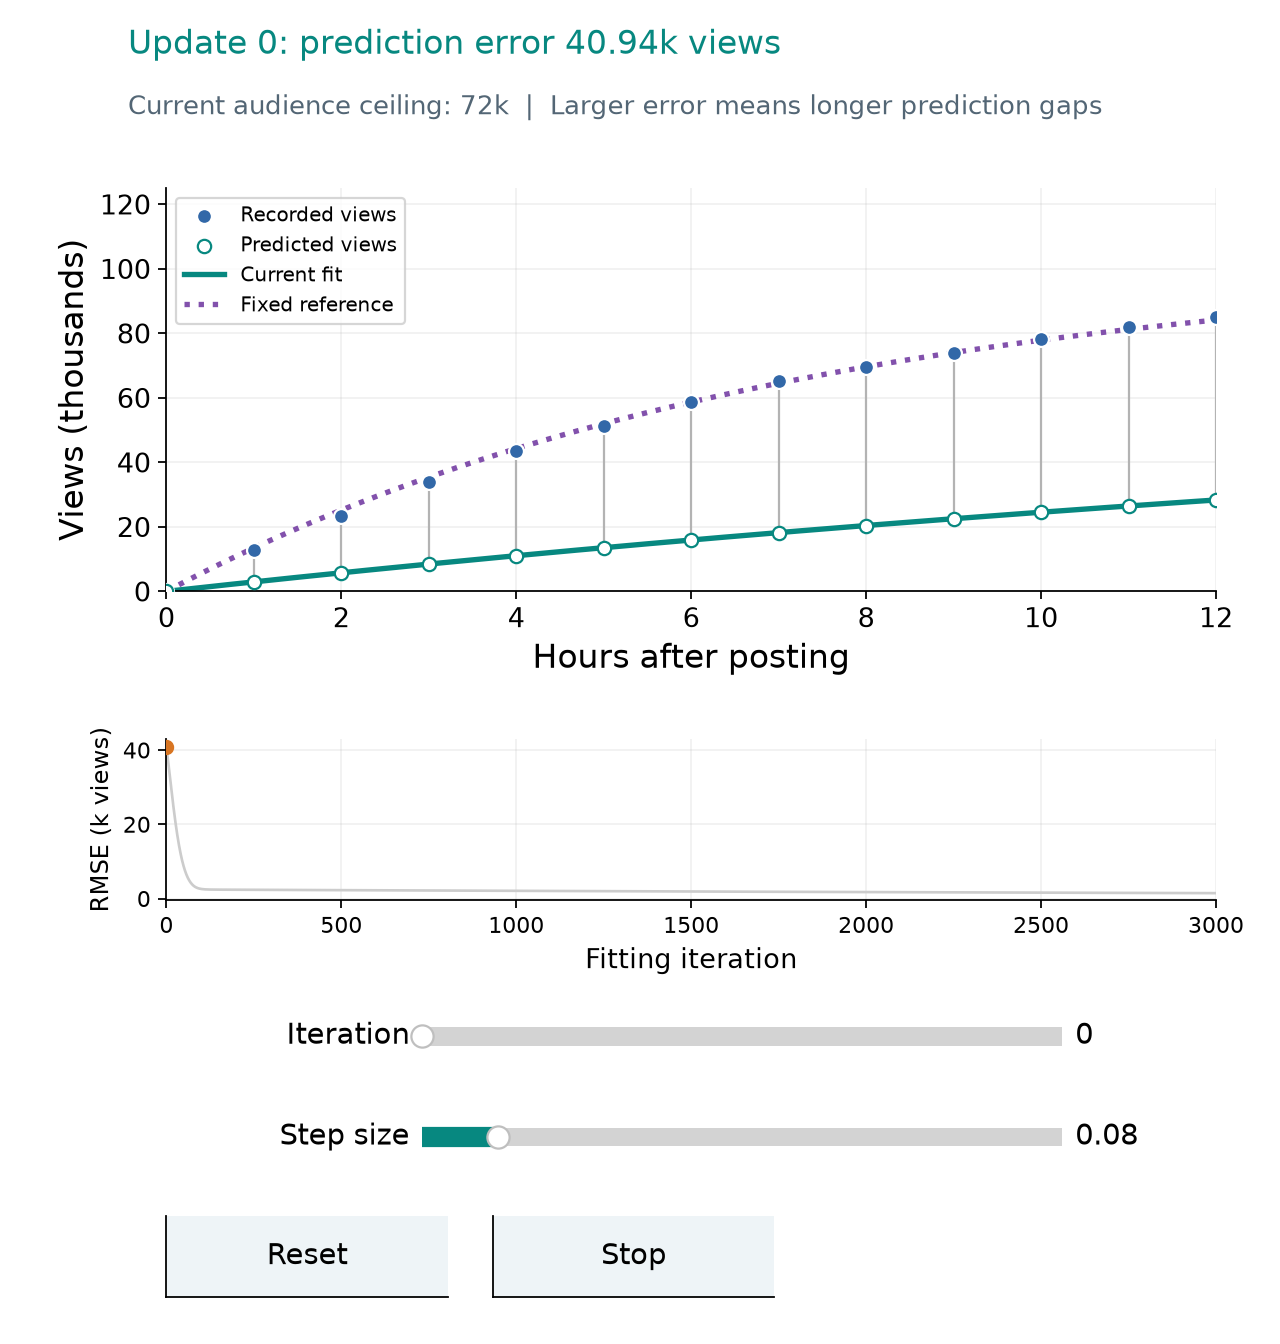

In [2]:
def render_video_fit(view, iteration, step_size):
    key = round(float(step_size), 4)
    if key not in video_iteration_cache:
        video_iteration_cache[key] = fit_video(step_size=key)
    history = video_iteration_cache[key]
    index = int(iteration)
    a, b, loss = history[index]
    reach, rate = a*reach_scale, b/time_scale
    predicted_train = video_curve(video_time_train, reach, rate)
    prediction = video_curve(video_train_grid, reach, rate)
    ax = view.ax
    video_records(ax, predicted_train)
    ax.plot(video_train_grid, prediction, color=TEAL, label="Current fit")
    ax.plot(video_train_grid, predict_video(video_train_grid), ":", color=PURPLE, label="Fixed reference")
    ax.set(xlim=(0, 12), ylim=(0, max(125, float(prediction.max())+10)))
    ax.legend(loc="upper left", fontsize=9)
    errors = np.sqrt(history[:, 2])*reach_scale
    view.history_ax.plot(np.arange(len(errors)), errors, color=".8", linewidth=1.2)
    view.history_ax.plot(np.arange(index+1), errors[:index+1], color=TEAL)
    view.history_ax.scatter([index], [errors[index]], color=ORANGE, s=35, zorder=5)
    view.history_ax.set(xlabel="Fitting iteration", ylabel="RMSE (k views)", xlim=(0, 3000))
    view.history_ax.tick_params(labelsize=10)
    view.history_ax.xaxis.label.set_size(12)
    view.history_ax.yaxis.label.set_size(11)
    view.status.set_text(f"Update {index}: prediction error {errors[index]:.2f}k views")
    view.detail.set_text(f"Current audience ceiling: {reach:.0f}k  |  Larger error means longer prediction gaps")
    return {"parameters": history[index, :2].copy(), "history": history, "iteration": index,
            "prediction": prediction, "training_prediction": predicted_train, "loss": loss}


video_fit_demo = RegressionExplorer("video_fit", render_video_fit, [
    ("iteration", "Iteration", 0, 3000, 0, 10, "%0.0f"),
    ("step_size", "Step size", .01, .6, .08, .01, "%0.2f"),
], history=True)
video_fit_demo.start()


## Tomorrow's views from today's records

The forecast-time control moves the orange prediction into the future. Both the saturation curve and the straight-line comparison are fitted to the same first 12 hours. Later records only evaluate them.

The line keeps adding views at a constant pace. The saturation curve slows down. A plausible shape can improve a forecast when the process follows that shape; it cannot guarantee the future. Mixing future records into fitting would give the model information unavailable at prediction time.


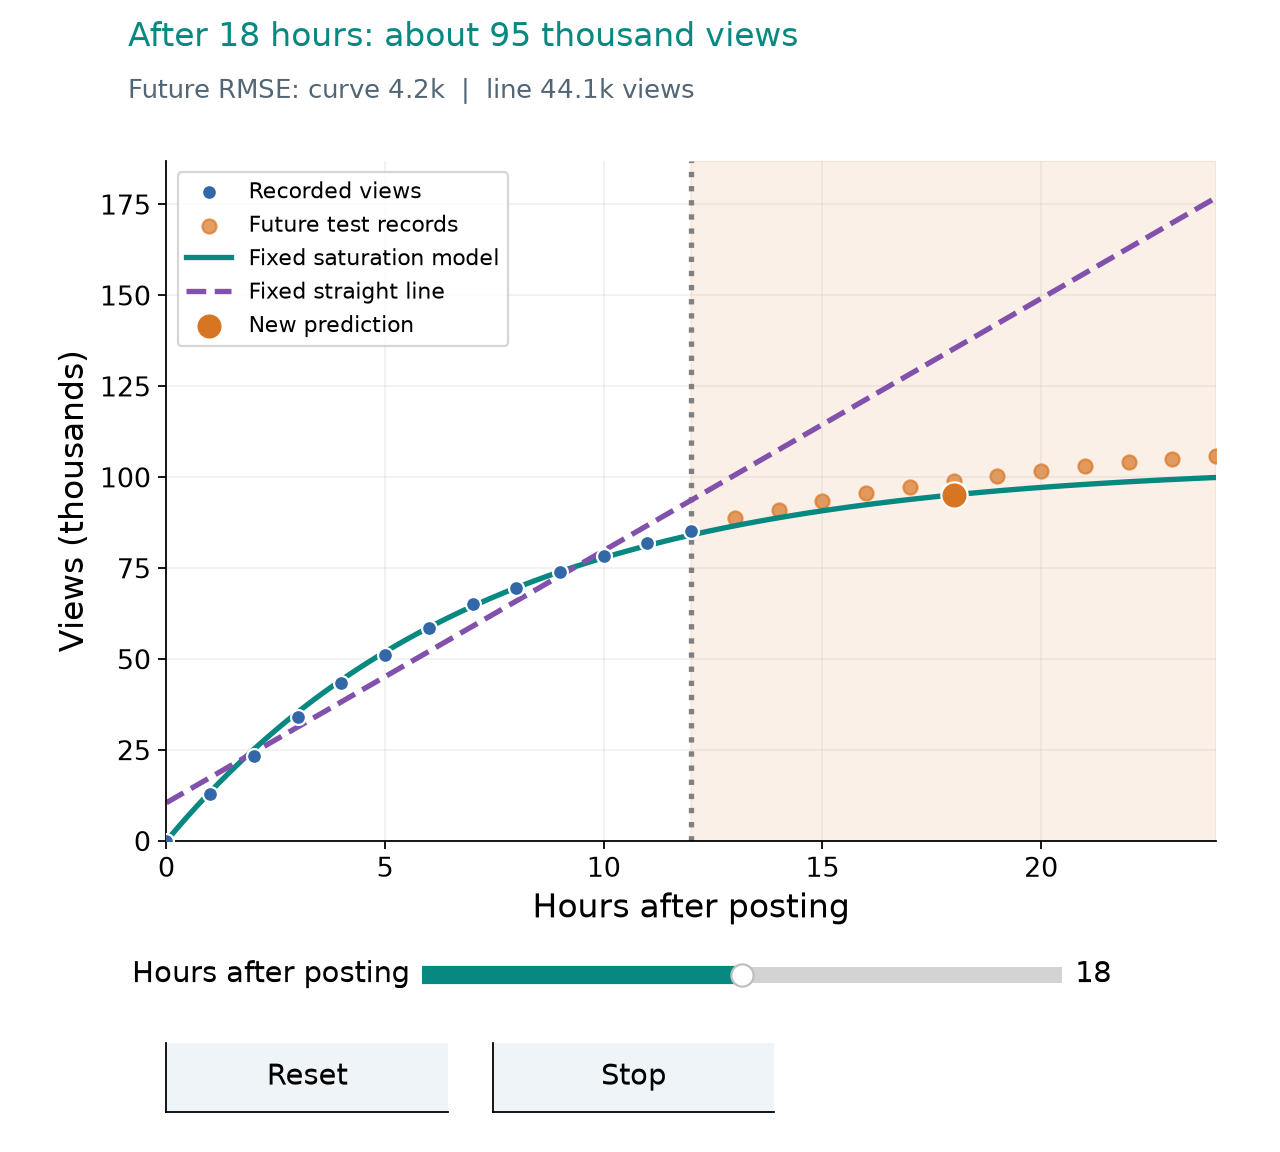

In [3]:
video_future_prediction = predict_video(video_time_future)
video_future_error = metrics(video_views_future, video_future_prediction)
linear_future_error = metrics(video_views_future, linear_video.predict(video_time_future[:, None]))


def render_video_forecast(view, hour):
    prediction = float(predict_video(hour))
    linear_prediction = float(linear_video.predict([[hour]])[0])
    ax = view.ax
    video_records(ax)
    ax.axvspan(12, 24, color=ORANGE, alpha=.10)
    ax.axvline(12, color=".5", linestyle=":")
    ax.scatter(video_time_future, video_views_future, color=ORANGE, s=40, alpha=.7, label="Future test records")
    ax.plot(video_grid, predict_video(video_grid), color=TEAL, label="Fixed saturation model")
    ax.plot(video_grid, linear_video.predict(video_grid[:, None]), "--", color=PURPLE, label="Fixed straight line")
    ax.scatter([hour], [prediction], color=ORANGE, edgecolor="white", s=140, zorder=5, label="New prediction")
    ax.set(xlim=(0, 24), ylim=(0, max(180, float(linear_video.predict([[24]])[0])+10)))
    ax.legend(loc="upper left", fontsize=10)
    view.status.set_text(f"After {hour:.0f} hours: about {prediction:.0f} thousand views")
    view.detail.set_text(f"Future RMSE: curve {video_future_error['RMSE']:.1f}k  |  line {linear_future_error['RMSE']:.1f}k views")
    return {"prediction": prediction, "linear_prediction": linear_prediction, "time": hour}


video_forecast_demo = RegressionExplorer("video_forecast", render_video_forecast, [
    ("hour", "Hours after posting", 12, 24, 18, 1, "%0.0f"),
])
video_forecast_demo.start()


## A large account reposts the clip

The original forecast knows nothing about a future repost. The extra-audience control determines how many additional views that event can eventually bring, and the repost-time control determines when they begin arriving.

The recorded past and the fitted model stay fixed. Both future scenarios reuse the same underlying variation, so their difference comes from the repost. At zero extra audience, the original future is recovered exactly. A later repost leaves less time for its effect to appear in the displayed window.


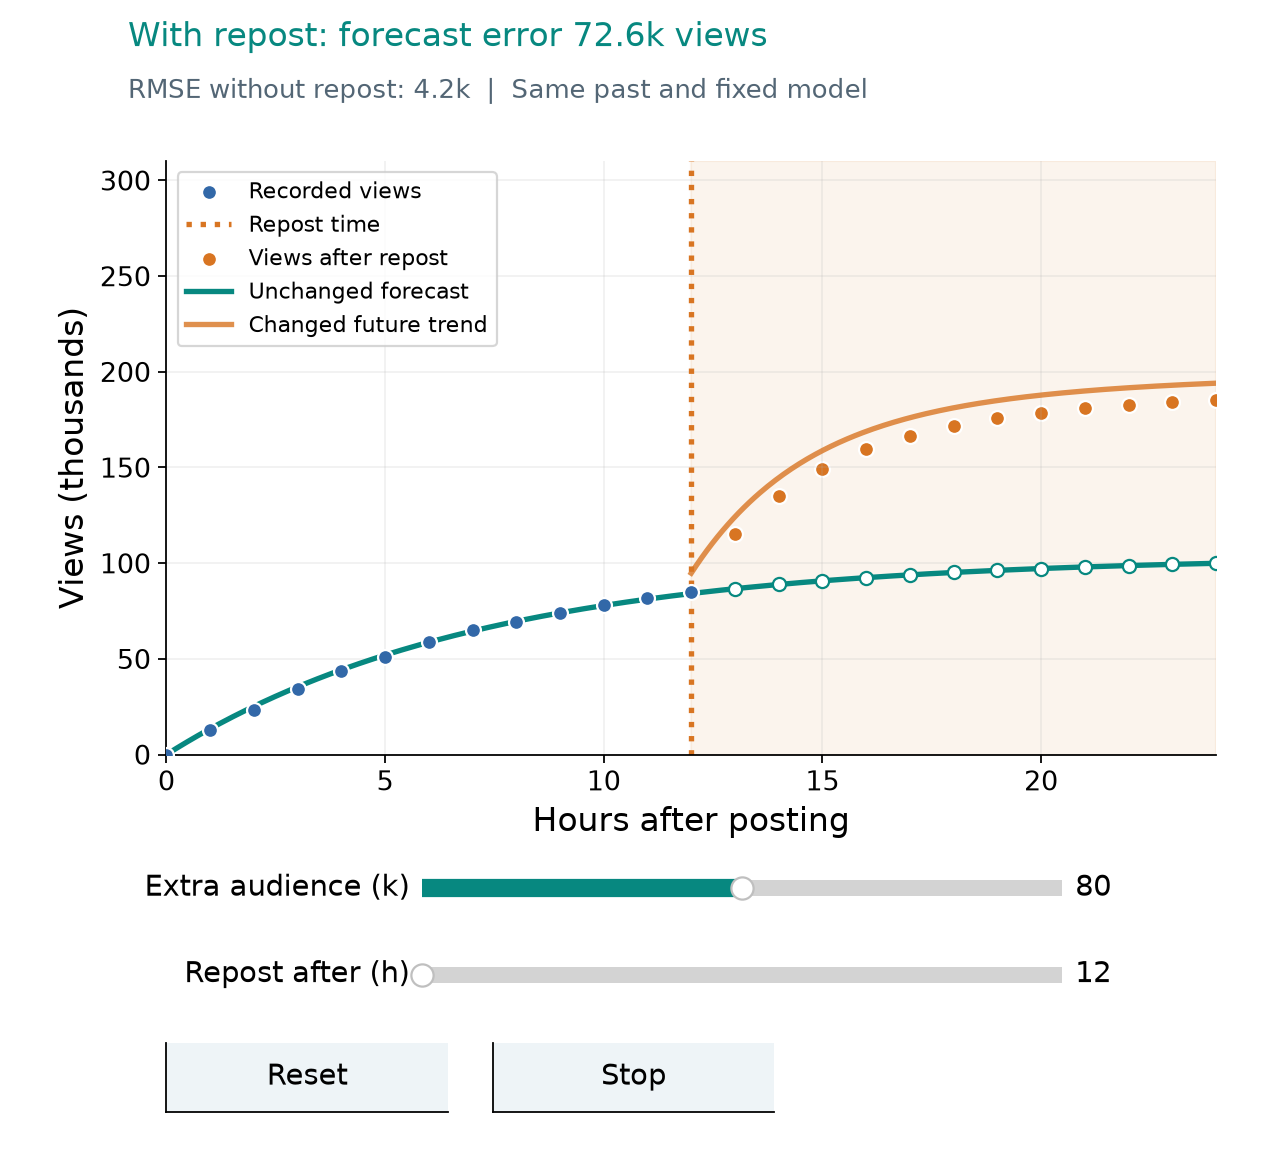

In [4]:
video_future_noise = video_views_future-video_mean(video_time_future)


def render_video_repost(view, extra_audience, repost_hour):
    added = video_curve(np.maximum(video_time_future-repost_hour, 0), extra_audience, .4)
    changed_mean = video_mean(video_time_future)+added
    observed = changed_mean+video_future_noise
    error = metrics(observed, video_future_prediction)
    future_grid = np.linspace(12, 24, 200)
    changed_curve = video_mean(future_grid)+video_curve(np.maximum(future_grid-repost_hour, 0), extra_audience, .4)
    ax = view.ax
    video_records(ax)
    ax.axvspan(12, 24, color=ORANGE, alpha=.08)
    ax.axvline(repost_hour, color=ORANGE, linestyle=":", label="Repost time")
    ax.scatter(video_time_future, observed, color=ORANGE, s=45, edgecolor="white", label="Views after repost")
    ax.plot(video_grid, predict_video(video_grid), color=TEAL, label="Unchanged forecast")
    ax.scatter(video_time_future, video_future_prediction, facecolors="white", edgecolors=TEAL, s=35, zorder=4)
    ax.plot(future_grid, changed_curve, color=ORANGE, alpha=.8, label="Changed future trend")
    ax.set(xlim=(0, 24), ylim=(0, 310))
    ax.legend(loc="upper left", fontsize=10)
    view.status.set_text(f"With repost: forecast error {error['RMSE']:.1f}k views")
    view.detail.set_text(f"RMSE without repost: {video_future_error['RMSE']:.1f}k  |  Same past and fixed model")
    return {"observed": observed, "changed_mean": changed_mean, "prediction": video_future_prediction.copy(),
            "metrics": error, "added": added, "repost_hour": repost_hour}


video_repost_demo = RegressionExplorer("video_repost", render_video_repost, [
    ("extra_audience", "Extra audience (k)", 0, 160, 80, 5, "%0.0f"),
    ("repost_hour", "Repost after (h)", 12, 20, 12, 1, "%0.0f"),
])
video_repost_demo.start()


Past success cannot tell a model about an unrecorded future event. Updated observations or an input describing reposts would provide missing information. A forecast remains an estimate under assumptions, not a promise about one video's eventual popularity.
